=== Numerieke detectie van bifurcatie-achtige veranderingen ===
Mu waar #roots verandert (ruw, via root-count): [-0.24975 -0.00075]
Mu waar stabiliteit r=0 wisselt (ruw): -0.000750
Tip: de saddle-node zit typisch waar er 2 roots bijkomen, de pitchfork/instabiliteit bij mu≈0.


/var/folders/9s/8sbwt7bs0m15y39npx_sphrc0000gn/T/ipykernel_59170/4281334947.py:299: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc="upper right")



=== Regio-samenvatting (numeriek, via cycles en stabiliteit) ===
μ=-0.400: origin = stable spiral; cycles=[]
  -> typisch: alles spiralt naar de oorsprong (geen limietcyclus).
μ=-0.100: origin = stable spiral; cycles=[(np.float64(0.336), 'unstable_cycle'), (np.float64(0.942), 'stable_cycle')]
  -> typisch: bistabiliteit: kleine r -> oorsprong, grote r -> stabiele limietcyclus; scheiding door onstabiele cyclus.
μ= 0.200: origin = unstable spiral; cycles=[(np.float64(1.082), 'stable_cycle')]
  -> typisch: oorsprong instabiel, trajecten gaan naar stabiele limietcyclus.


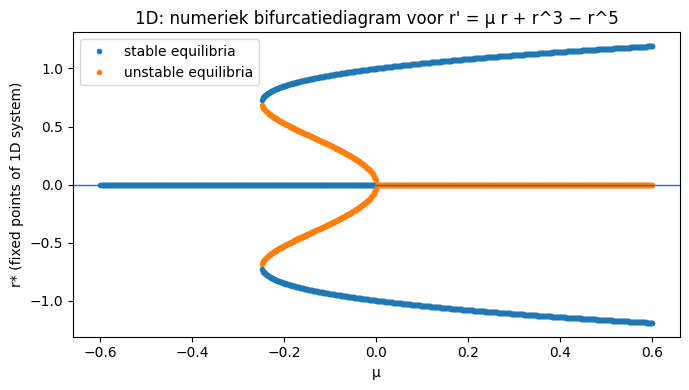

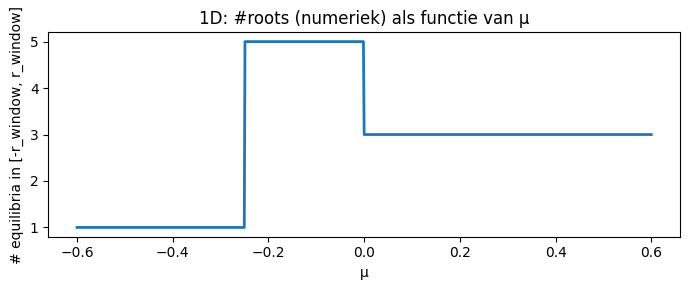

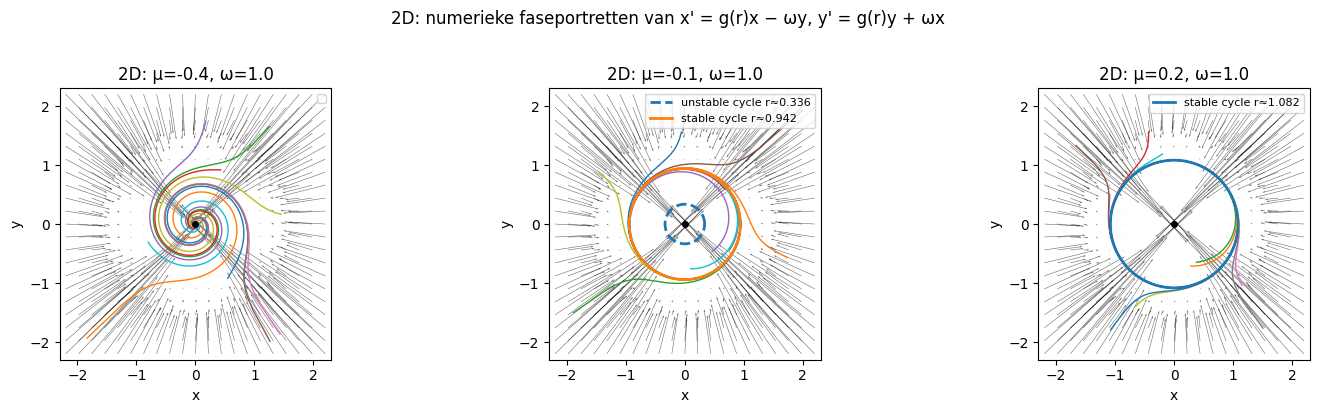

In [1]:
"""
Numerieke uitwerking (a,b,c) voor:
    r' = μ r + r^3 - r^5

- (a) 1D: vind evenwichten en stabiliteit numeriek + bifurcatiediagram
- (b) 2D: zet om naar (x,y) met constante ω = θ' ≠ 0, simuleer faseportretten
- (c) numerieke “regio”-samenvatting via root counts + stabiliteit

Dependencies: numpy, scipy, matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar


# ----------------------------
# 1D systeem: r' = f(r; μ)
# ----------------------------
def f_r(r, mu):
    return mu * r + r**3 - r**5


def df_dr(r, mu):
    # analytisch afgeleid (mag; maar je kan dit ook finite-diff doen)
    return mu + 3 * r**2 - 5 * r**4


def find_roots_1d(mu, r_min=-3.0, r_max=3.0, n_scan=8001, tol=1e-6):
    """
    Vind alle reële nulpunten van f_r(r, mu) in [r_min, r_max] numeriek:
    - scan op sign changes
    - brentq per interval
    - dedupe op tolerantie
    """
    r_grid = np.linspace(r_min, r_max, n_scan)
    y = f_r(r_grid, mu)

    roots = []
    for i in range(len(r_grid) - 1):
        y0, y1 = y[i], y[i + 1]
        if np.isnan(y0) or np.isnan(y1):
            continue

        # exact 0 op gridpunt
        if abs(y0) < 1e-12:
            roots.append(r_grid[i])
            continue

        # sign change => root in (ri, ri+1)
        if y0 * y1 < 0:
            a, b = r_grid[i], r_grid[i + 1]
            try:
                sol = root_scalar(lambda rr: f_r(rr, mu), bracket=(a, b), method="brentq")
                if sol.converged:
                    roots.append(sol.root)
            except ValueError:
                pass

    # dedupe
    roots = sorted(roots)
    unique = []
    for r in roots:
        if not unique or abs(r - unique[-1]) > tol:
            unique.append(r)
    return np.array(unique)


def classify_stability_1d(r_star, mu):
    """
    Voor 1D: r* stabiel als f'(r*) < 0
    """
    lam = df_dr(r_star, mu)
    if lam < 0:
        return "stable"
    if lam > 0:
        return "unstable"
    return "neutral"


def bifurcation_diagram_1d(mu_vals, r_window=3.0):
    """
    Bouw data voor bifurcatiediagram:
    (mu, r*) punten + stabiliteit.
    """
    stable_pts = []
    unstable_pts = []

    for mu in mu_vals:
        roots = find_roots_1d(mu, r_min=-r_window, r_max=r_window)
        for r_star in roots:
            st = classify_stability_1d(r_star, mu)
            if st == "stable":
                stable_pts.append((mu, r_star))
            elif st == "unstable":
                unstable_pts.append((mu, r_star))

    stable_pts = np.array(stable_pts) if stable_pts else np.empty((0, 2))
    unstable_pts = np.array(unstable_pts) if unstable_pts else np.empty((0, 2))
    return stable_pts, unstable_pts


def detect_bifurcations_by_root_count(mu_vals, r_window=3.0):
    """
    Puur numeriek: detecteer mu's waar #roots verandert (saddle-node etc.)
    + markeer mu waar stabiliteit van r=0 wisselt (μ=0).
    """
    counts = []
    for mu in mu_vals:
        roots = find_roots_1d(mu, r_min=-r_window, r_max=r_window)
        counts.append(len(roots))
    counts = np.array(counts)

    # waar count verandert
    changes = np.where(counts[1:] != counts[:-1])[0]
    approx_changes = []
    for idx in changes:
        approx_changes.append(0.5 * (mu_vals[idx] + mu_vals[idx + 1]))

    # waar stabiliteit van r=0 verandert (numeriek: teken van μ)
    # (r=0 eigenwaarde = μ)
    sign_changes = np.where(np.sign(mu_vals[1:]) != np.sign(mu_vals[:-1]))[0]
    approx_mu0 = None
    if len(sign_changes) > 0:
        j = sign_changes[0]
        approx_mu0 = 0.5 * (mu_vals[j] + mu_vals[j + 1])

    return counts, approx_changes, approx_mu0


# ----------------------------
# 2D systeem met ω = θ' ≠ 0
#   r' = f(r; μ), θ' = ω
# => x' = g(r)*x - ω y
#    y' = g(r)*y + ω x
# met g(r) = f(r)/r = μ + r^2 - r^4 (continu met g(0)=μ)
# ----------------------------
def rhs_xy(t, z, mu, omega):
    x, y = z
    r2 = x * x + y * y
    g = mu + r2 - r2 * r2
    dx = g * x - omega * y
    dy = g * y + omega * x
    return [dx, dy]


def integrate_xy(mu, omega, z0, t_end=80.0, n_eval=4000, rtol=1e-8, atol=1e-10):
    t_eval = np.linspace(0.0, t_end, n_eval)
    sol = solve_ivp(
        fun=lambda t, z: rhs_xy(t, z, mu, omega),
        t_span=(0.0, t_end),
        y0=np.array(z0, dtype=float),
        t_eval=t_eval,
        rtol=rtol,
        atol=atol,
        method="RK45",
    )
    return sol


def limit_cycle_radii_numeric(mu, r_max=3.0, n_scan=4001, tol=1e-6):
    """
    Puur numeriek: vind positieve radii r>0 met r' = 0:
        f(r)=0  <=> μ r + r^3 - r^5 = 0
    maar we zoeken enkel r>0 oplossingen.

    We scannen op sign changes van f(r) op r>0 en doen brentq.
    """
    r_grid = np.linspace(0.0, r_max, n_scan)
    y = f_r(r_grid, mu)

    roots = []
    for i in range(len(r_grid) - 1):
        y0, y1 = y[i], y[i + 1]
        if abs(y0) < 1e-12 and r_grid[i] > 0:
            roots.append(r_grid[i])
            continue
        if y0 * y1 < 0:
            a, b = r_grid[i], r_grid[i + 1]
            if a == 0:
                a = 1e-12
            try:
                sol = root_scalar(lambda rr: f_r(rr, mu), bracket=(a, b), method="brentq")
                if sol.converged and sol.root > 0:
                    roots.append(sol.root)
            except ValueError:
                pass

    roots = sorted(roots)
    unique = []
    for r in roots:
        if not unique or abs(r - unique[-1]) > tol:
            unique.append(r)
    return np.array(unique)


def classify_cycle_stability(r_star, mu):
    """
    Stabiliteit van limietcyclus in dit radiaal-systeem:
    zelfde criterium als 1D: f'(r*) < 0 => stabiele cyclus
    """
    lam = df_dr(r_star, mu)
    if lam < 0:
        return "stable_cycle"
    if lam > 0:
        return "unstable_cycle"
    return "neutral_cycle"


# ----------------------------
# Main: plots + numerieke samenvatting
# ----------------------------
if __name__ == "__main__":
    # ---- instellingen ----
    omega = 1.0  # kies θ' ≠ 0
    r_window = 3.0

    # fijn mu-grid voor diagram
    mu_vals = np.linspace(-0.6, 0.6, 801)

    # ---- (a) 1D bifurcatiediagram numeriek ----
    stable_pts, unstable_pts = bifurcation_diagram_1d(mu_vals, r_window=r_window)
    counts, approx_changes, approx_mu0 = detect_bifurcations_by_root_count(mu_vals, r_window=r_window)

    print("=== Numerieke detectie van bifurcatie-achtige veranderingen ===")
    print(f"Mu waar #roots verandert (ruw, via root-count): {np.round(approx_changes, 6)}")
    if approx_mu0 is not None:
        print(f"Mu waar stabiliteit r=0 wisselt (ruw): {approx_mu0:.6f}")
    print("Tip: de saddle-node zit typisch waar er 2 roots bijkomen, de pitchfork/instabiliteit bij mu≈0.")

    fig1, ax1 = plt.subplots(figsize=(7, 4))
    if len(stable_pts) > 0:
        ax1.plot(stable_pts[:, 0], stable_pts[:, 1], ".", label="stable equilibria")
    if len(unstable_pts) > 0:
        ax1.plot(unstable_pts[:, 0], unstable_pts[:, 1], ".", label="unstable equilibria")
    ax1.axhline(0, lw=1)
    ax1.set_xlabel("μ")
    ax1.set_ylabel("r* (fixed points of 1D system)")
    ax1.set_title("1D: numeriek bifurcatiediagram voor r' = μ r + r^3 − r^5")
    ax1.legend()
    plt.tight_layout()

    # extra: root count vs mu
    fig2, ax2 = plt.subplots(figsize=(7, 3))
    ax2.plot(mu_vals, counts, lw=2)
    ax2.set_xlabel("μ")
    ax2.set_ylabel("# equilibria in [-r_window, r_window]")
    ax2.set_title("1D: #roots (numeriek) als functie van μ")
    plt.tight_layout()

    # ---- (b) 2D numerieke faseportretten + limietcycli ----
    mu_examples = [-0.40, -0.10, 0.20]  # < -0.25, tussen (-0.25,0), >0
    fig3, axes = plt.subplots(1, 3, figsize=(15, 4))

    rng = np.random.default_rng(0)
    for ax, mu in zip(axes, mu_examples):
        # vector field (grof)
        grid = np.linspace(-2.2, 2.2, 21)
        X, Y = np.meshgrid(grid, grid)
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                u, v = rhs_xy(0.0, (X[i, j], Y[i, j]), mu, omega)
                U[i, j], V[i, j] = u, v

        ax.quiver(X, Y, U, V, angles="xy", scale_units="xy", scale=60, width=0.002, alpha=0.6)

        # numeriek gevonden cyclus-radii (r>0 oplossingen)
        r_roots = limit_cycle_radii_numeric(mu, r_max=3.0)
        for r_star in r_roots:
            st = classify_cycle_stability(r_star, mu)
            theta = np.linspace(0, 2 * np.pi, 400)
            cx = r_star * np.cos(theta)
            cy = r_star * np.sin(theta)
            if st == "stable_cycle":
                ax.plot(cx, cy, lw=2, label=f"stable cycle r≈{r_star:.3f}")
            else:
                ax.plot(cx, cy, "--", lw=2, label=f"unstable cycle r≈{r_star:.3f}")

        # trajecten vanaf random startpunten
        for _ in range(10):
            z0 = rng.uniform(-2.0, 2.0, size=2)
            # vermijd exact (0,0)
            if np.linalg.norm(z0) < 1e-6:
                z0 = np.array([1e-3, 0.0])

            sol = integrate_xy(mu, omega, z0, t_end=60.0, n_eval=2500)
            ax.plot(sol.y[0], sol.y[1], lw=1)

        ax.plot(0, 0, "ko", ms=4)
        ax.set_aspect("equal", "box")
        ax.set_xlim(-2.3, 2.3)
        ax.set_ylim(-2.3, 2.3)
        ax.set_title(f"2D: μ={mu}, ω={omega}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend(fontsize=8, loc="upper right")

    fig3.suptitle("2D: numerieke faseportretten van x' = g(r)x − ωy, y' = g(r)y + ωx", y=1.02)
    plt.tight_layout()

    # ---- (c) numerieke “regio”-samenvatting printen ----
    print("\n=== Regio-samenvatting (numeriek, via cycles en stabiliteit) ===")
    for mu in mu_examples:
        origin_stable = (mu < 0)  # eigenwaarden μ ± iω
        r_roots = limit_cycle_radii_numeric(mu, r_max=3.0)
        cycles = [(r, classify_cycle_stability(r, mu)) for r in r_roots]
        print(f"μ={mu: .3f}: origin = {'stable spiral' if origin_stable else 'unstable spiral'}; cycles={[(round(r,3), s) for r,s in cycles]}")

        if mu < -0.25:
            print("  -> typisch: alles spiralt naar de oorsprong (geen limietcyclus).")
        elif -0.25 < mu < 0:
            print("  -> typisch: bistabiliteit: kleine r -> oorsprong, grote r -> stabiele limietcyclus; scheiding door onstabiele cyclus.")
        else:
            print("  -> typisch: oorsprong instabiel, trajecten gaan naar stabiele limietcyclus.")

    plt.show()
